In [ ]:
# BIBLIOTECAS
from faker import Faker
import pandas as pd
from google.colab import files
import random
import matplotlib.pyplot as plt
from datetime import datetime
fake = Faker('pt_BR') # geração de dados do tipo Português - Br

# Este script tem objetivo de criar um Conjunto de Dados Falsos ou Alegóricos para imitar um cenário de negócios de uma operadora de telecomunicações

In [ ]:
# Lista de cargos
cargos = [
    "Analista financeiro",
    "Servidor público",
    "Enfermeiro",
    "Professor",
    "Mecânico",
    "Programador",
    "Engenheiro",
    "Policial Civil",
    "Médico",
    "Contador"
]

In [ ]:
# Lista de Planos
planos = [
    "Plano Básico",
    "Plano Pro",
    "Plano Full"
]

In [ ]:
# Lista de Técnicos
tecnicos = [
    "Marcelo Vieira",
    "Jacson Soares",
    "Eduardo Campos",
    "Genilson Junior"
]

In [ ]:
# Funcao para gerar uma Tabela de Clientes registrados
def gerarCadastro():
    nome = fake.name()
    idade = random.randint(18,75)
    cargo = random.choice(cargos)
    plano = random.choice(planos)
    if(plano == "Plano Básico"):
      valorBoleto = 99.90
    elif(plano == "Plano Pro"):
      valorBoleto = 124.90
    else: # plano Full
      valorBoleto = 159.90
    dataAssinatura = fake.date_between(start_date='-5y', end_date='today').strftime("%y-%m-%d")
    telefone = fake.phone_number()
    id = str(random.randint(100,999))
    #
    return {
        "id": id,
        "nome": nome,
        "idade": idade,
        "cargo": cargo,
        "plano": plano,
        "valorBoleto": valorBoleto,
        "dataAssinatura": dataAssinatura,
        "telefone": telefone
    }

In [ ]:
# Funcao para gerar uma Tabela de Instalacoes de ONT's
def gerarRegistroInstalacao(id_cliente,dataAssinatura):
  nome_tecnico = random.choice(tecnicos)
  # Convert dataAssinatura string to datetime object for faker
  parsed_dataAssinatura = datetime.strptime(dataAssinatura, "%y-%m-%d")
  dataInstalacao = fake.date_between(start_date=parsed_dataAssinatura, end_date='today').strftime("%y-%m-%d") # Instalação pode ser na mesma data ou depois da assinatura
  sinal = random.randint(-33,-18) # Valores de sinal em dBm, -18 é bom, -33 é ruim
  if(sinal <= -26):
    status = "Crítico"
  else:
    status = "Normal"
  reclamacoes_Ultimos90dias = random.randint(0,10)
  return {
      "id_cliente": id_cliente,
      "tecnicos": nome_tecnico,
      "dataInstalacao": dataInstalacao,
      "sinal_dbm": sinal,
      "status_sinal": status,
      "reclamacoes_90dias": reclamacoes_Ultimos90dias
  }

### Gerando Dados Falsos para Exportar(formato .xlsx)

In [ ]:
#
dadosCadastro = []
N = 100 # Nº de registros
for i in range(N):
    dadosCadastro.append(gerarCadastro())

In [ ]:
#
dadosRegistroInstalacoes = []
for i in range(len(dadosCadastro)):
  # Acessa a lista de dicionários 'dadosCadastro' individualmente por registro para poder acessar os valores e repassar os dados um por um
  cadastro_cliente = dadosCadastro[i]
  # Chama a função gerarRegistroInstalacao com os dados do cliente e anexa o resultado
  dadosRegistroInstalacoes.append(gerarRegistroInstalacao(id_cliente=cadastro_cliente['id'], dataAssinatura=cadastro_cliente['dataAssinatura']))

### Análise de Dados Gerais com Dataframes

In [ ]:
# Criando DataFrames
df_cliente = pd.DataFrame(dadosCadastro)
df_instalacao = pd.DataFrame(dadosRegistroInstalacoes)
#
#

In [ ]:
# TABELA CLIENTES
print(">>>> Primeiros registros do Dataframe <<<<")
display(df_cliente.head()) # Exibe 5 primeiros registros
print(">>>> Resumo da tabela <<<<")
display(df_cliente.info()) # Resumo do dataframe
print(">>>> Resumo estatistico dos dados numéricos <<<<")
display(df_cliente.describe()) # Resumo estatístico dos dados numéricos
#
#
#
#
print("\n\n#############################################################\n\n")
#
# TABELA DE INSTALACOES
print(">>>> Primeiros registros do Dataframe <<<<")
display(df_instalacao.head()) # Exibe 5 primeiros registros
print(">>>> Resumo da tabela <<<<")
display(df_instalacao.info()) # Resumo do dataframe
print(">>>> Resumo estatistico dos dados numéricos <<<<")
display(df_instalacao.describe()) # Resumo estatístico dos dados numéricos
#


>>>> Primeiros registros do Dataframe <<<<


,id,nome,idade,cargo,plano,valorBoleto,dataAssinatura,telefone
0,933,Ravi Lucca Camargo,26,Policial Civil,Plano Pro,124.9,22-07-20,41 8270-1201
1,729,Maya da Paz,63,Mecânico,Plano Full,159.9,21-09-26,51 4179 7339
2,410,Nathan Pacheco,57,Professor,Plano Full,159.9,24-08-15,+55 51 4381 0257
3,255,Ian Borges,24,Engenheiro,Plano Pro,124.9,23-04-02,(051) 0073 3214
4,343,Liz Pimenta,53,Professor,Plano Pro,124.9,24-02-08,21 3362-3226


>>>> Resumo da tabela <<<<
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              100 non-null    object 
 1   nome            100 non-null    object 
 2   idade           100 non-null    int64  
 3   cargo           100 non-null    object 
 4   plano           100 non-null    object 
 5   valorBoleto     100 non-null    float64
 6   dataAssinatura  100 non-null    object 
 7   telefone        100 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 6.4+ KB


None

>>>> Resumo estatistico dos dados numéricos <<<<


...

,id_cliente,tecnicos,dataInstalacao,sinal_dbm,status_sinal,reclamacoes_90dias
0,933,Eduardo Campos,25-09-06,-23,Normal,9
1,729,Genilson Junior,24-12-29,-33,Crítico,8
2,410,Jacson Soares,24-10-16,-19,Normal,9
3,255,Genilson Junior,25-04-24,-18,Normal,7
4,343,Jacson Soares,24-05-20,-24,Normal,3


>>>> Resumo da tabela <<<<
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id_cliente          100 non-null    object
 1   tecnicos            100 non-null    object
 2   dataInstalacao      100 non-null    object
 3   sinal_dbm           100 non-null    int64 
 4   status_sinal        100 non-null    object
 5   reclamacoes_90dias  100 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 4.8+ KB


None

>>>> Resumo estatistico dos dados numéricos <<<<


,sinal_dbm,reclamacoes_90dias
count,100.000000,100.000000
mean,-25.590000,5.430000
std,4.463307,3.207488
min,-33.000000,0.000000
25%,-29.000000,3.000000
50%,-25.500000,6.000000
75%,-21.000000,8.000000
max,-18.000000,10.000000


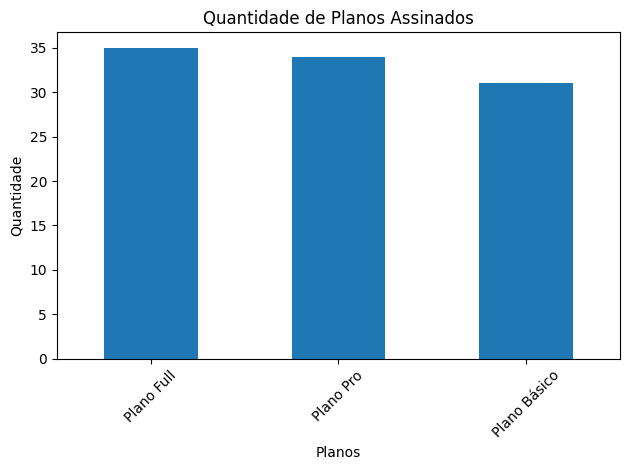

In [ ]:

# Estrutura utilizando Matplotlib
df_cliente['plano'].value_counts().plot(kind='bar',title='Quantidade de Planos Assinados')
plt.xlabel("Planos")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Exportando como arquivo .xlsx para ser lido no Excel
df_cliente.to_excel('dadosFalsosCliente.xlsx', index=False)
files.download('dadosFalsosCliente.xlsx')
#
df_instalacao.to_excel('dadosFalsosInstalacao.xlsx', index=False)
files.download('dadosFalsosInstalacao.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>